```
---
title: Black list of small molecules in Rhea-BioPAX
tags: BioPAX, smallMolecules, SPARQL, Rhea, ChEBI, blacklist
lang: en
version: 0.3
date: 2026-07-06
---
```

In [1]:
#import importlib
import IPython
#import json
import matplotlib.pyplot as plt
#import networkx as nx
#import os
import pandas
#import rdflib
#import rdflib.namespace
import sparqldataframe
from SPARQLWrapper import SPARQLWrapper, JSON
#import sys

In [2]:
#reactomeVersion = 96 # 2026-03-25
#chebiVersion = 252 # CHECKED BY QUERY BELOW
#endpointURL = "http://localhost:3030/reactome/query"
#endpointURL = "http://localhost:3030/chebi/query"
#endpointURL = "http://localhost:3030/reactomeChEBI/query"
endpointURL = "http://localhost:3030/rhea/query"
rdfFormat = "turtle"

In [3]:
prefixes = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>

PREFIX CHEBI: <http://purl.obolibrary.org/obo/CHEBI_>
PREFIX chebirel: <http://purl.obolibrary.org/obo/CHEBI#>
PREFIX oboInOwl: <http://www.geneontology.org/formats/oboInOwl#>

PREFIX bp3: <http://www.biopax.org/release/biopax-level3.owl#>

PREFIX rhea: <http://biopax.rhea-db.org/level3/>
PREFIX rheadb: <http://rdf.rhea-db.org/>
"""

In [4]:
query="""
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>

SELECT ?ontology ?versionIRI (REPLACE(REPLACE(STR(?versionIRI), 'http://purl.obolibrary.org/obo/chebi/', ''), '/chebi.owl', '') AS ?versionNumber)
WHERE {
  ?ontology rdf:type owl:Ontology .
  ?ontology owl:versionIRI ?versionIRI .
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

chebiVersion = int(results["results"]["bindings"][0]["versionNumber"]["value"])
print("ChEBI version: {}".format(chebiVersion))

ChEBI version: 252


In [5]:
query="""
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>
PREFIX bp3: <http://www.biopax.org/release/biopax-level3.owl#>

SELECT DISTINCT ?versionNumber
WHERE {
  ?xref rdf:type bp3:RelationshipXref .
  ?xref bp3:db "Rhea" .
  ?xref bp3:dbVersion ?versionNumber .
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

rheaVersion = int(results["results"]["bindings"][0]["versionNumber"]["value"])
print("Rhea version: {}".format(rheaVersion))

Rhea version: 141


In [6]:
def displaySparqlResults(results):
    '''
    Displays as HTML the result of a SPARQLWrapper query in a Jupyter notebook.
    
        Parameters:
            results (dictionnary): the result of a call to SPARQLWrapper.query().convert()
    '''
    variableNames = results['head']['vars']
    tableCode = '<table><tr><th>{}</th></tr><tr>{}</tr></table>'.format('</th><th>'.join(variableNames), '</tr><tr>'.join('<td>{}</td>'.format('</td><td>'.join([row[vName]['value'] if vName in row.keys() else "&nbsp;" for vName in variableNames]))for row in results["results"]["bindings"]))
    IPython.display.display(IPython.display.HTML(tableCode))

# 1. General metrics

## 1.1 Reactions

In [7]:
query = """
SELECT (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type bp3:BiochemicalReaction .
  #?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

print("Nb biochemical reactions (direct): {}".format(results["results"]["bindings"][0]["nbReactions"]["value"]))


Nb biochemical reactions (direct): 67844


In [8]:
query = """
SELECT (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  #?reaction rdf:type bp3:BiochemicalReaction .
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

print("Nb biochemical reactions (indirect): {}".format(results["results"]["bindings"][0]["nbReactions"]["value"]))


Nb biochemical reactions (indirect): 69256


In [9]:
query = """
SELECT (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  #?reaction rdf:type bp3:BiochemicalReaction .
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction bp3:comment "RHEA:Direction=undefined" .
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

print("Nb master biochemical reactions (indirect): {}".format(results["results"]["bindings"][0]["nbReactions"]["value"]))

Nb master biochemical reactions (indirect): 17314


In [10]:
query = """
SELECT ?reactionType (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction rdf:type ?reactionType .
}
GROUP BY ?reactionType
ORDER BY DESC(?nbReactions)
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

reactionType,nbReactions
http://www.biopax.org/release/biopax-level3.owl#BiochemicalReaction,67844
http://www.biopax.org/release/biopax-level3.owl#TransportWithBiochemicalReaction,1412


In [11]:
query = """
SELECT ?reactionType (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction rdf:type ?reactionType .
  ?reaction bp3:comment "RHEA:Direction=undefined" .
}
GROUP BY ?reactionType
ORDER BY DESC(?nbReactions)
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

reactionType,nbReactions
http://www.biopax.org/release/biopax-level3.owl#BiochemicalReaction,16961
http://www.biopax.org/release/biopax-level3.owl#TransportWithBiochemicalReaction,353


<div class="alert alert-block alert-danger">
<b>There are 4 versions of each Rhea reaction</b> 
    <ul>
        <li>RHEA:Direction=undefined</li>
        <li>RHEA:Direction=left to right</li>
        <li>RHEA:Direction=right to left</li>
        <li>RHEA:Direction=bidirectional</li>
    </ul>
<b>The master reaction has direction "undefined"</b>
</div>

## 1.2 Small molecules and mapping to ChEBI

In [12]:
query = """
SELECT ?moleculeType (COUNT(DISTINCT ?molecule) AS ?nbMolecules)
WHERE {
  ?molecule rdf:type/(rdfs:subClassOf*) bp3:SmallMolecule .
  ?molecule rdf:type ?moleculeType .
}
GROUP BY ?moleculeType
ORDER BY DESC(?nbMolecules)
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

moleculeType,nbMolecules
http://www.biopax.org/release/biopax-level3.owl#SmallMolecule,360180


In [13]:
query = """
SELECT (COUNT(DISTINCT ?chebiID) AS ?nbMoleculesChEBI)
WHERE {
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ]
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

nbMoleculesChEBI
12950


In [14]:
query = """
SELECT DISTINCT ?chebiID ?moleculeChebiLabel
WHERE {
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ]
  
  # ChEBI URL -> ident
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) 
  #
  # ChEBI ident -> URL
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) 
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
}
"""

df = sparqldataframe.query(endpointURL, prefixes+query)
print("Nb ChEBI identifiers with label: {}".format(len(df)))
print("Nb distinct ChEBI identifiers: {}".format(len(set(df['chebiID']))))
df.to_csv("results/rhea_version{}_chebiMolecules.tsv.gz".format(rheaVersion), sep="\t", header=True, index=False)

Nb ChEBI identifiers with label: 12948
Nb distinct ChEBI identifiers: 12948


In [15]:
query = """
SELECT DISTINCT ?chebiID ?moleculeChebiDeprecated
WHERE {
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ]

  # ChEBI URL -> ident
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) 
  #
  # ChEBI ident -> URL
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi)

  FILTER NOT EXISTS {
    ?moleculeChebi rdfs:label ?moleculeChebiLabel .
  }

  OPTIONAL { ?moleculeChebi owl:deprecated ?moleculeChebiDeprecated . }
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

chebiID,moleculeChebiDeprecated
CHEBI:193521,true
CHEBI:87164,true


<div class="alert alert-block alert-danger">
<b>2 ChEBI identifiers used by Rhea v141 correspond to deprecated ChEBI molecules, that do not have any value for rdfs:label</b> 
    <ul>
        <li>CHEBI:193521</li>
        <li>CHEBI:87164</li>
    </ul>
</div>

# 2. Distribution nb of reactions by molecule

In [16]:
query = """
SELECT ?chebiID ?moleculeChebiLabel (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction bp3:comment "RHEA:Direction=undefined" .
  #?reaction (bp3:left|bp3:right)/(bp3:component*) ?molecule .
  ?reaction (bp3:left|bp3:right) ?molecule .

  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated ?moleculeChebiDeprecated . }
}
GROUP BY ?chebiID ?moleculeChebiLabel
ORDER BY DESC(?nbReactions)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbReactions'] = pandas.to_numeric(df['nbReactions'], downcast = 'integer', errors = 'coerce')

#df.to_csv("results/rhea_version{}_chebiMoleculesNbReactions.tsv.gz".format(rheaVersion), sep="\t", header=True, index=False)

print("Nb molecules ChEBI molecules associated to >= 1 reaction: {}".format(len(set(df['chebiID']))))

Nb molecules ChEBI molecules associated to >= 1 reaction: 12864


<div class="alert alert-block alert-warning">
<b>12,948 - 12,864 = 84</b> Rhea molecules are neither consumed nor produced by some chemical reactions, even as components of complexes.
</div>

In [17]:
query = """
SELECT DISTINCT ?chebiID ?moleculeChebiLabel ?nbReactions
WHERE {
  {
    SELECT ?chebiID ?moleculeChebiLabel (COUNT(DISTINCT ?reaction) AS ?nbReactions)
    WHERE {
      ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
      ?reaction bp3:comment "RHEA:Direction=undefined" .
      ?reaction (bp3:left|bp3:right) ?molecule .

      ?molecule rdf:type bp3:SmallMolecule .
      ?molecule bp3:entityReference/bp3:xref [
        rdf:type bp3:UnificationXref ;
        bp3:db "ChEBI" ;
        bp3:id ?chebiID
      ] .
      #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
      BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
      ?moleculeChebi rdfs:label ?moleculeChebiLabel .
      FILTER NOT EXISTS { ?moleculeChebi owl:deprecated ?moleculeChebiDeprecated . }
    }
    GROUP BY ?chebiID ?moleculeChebiLabel
  }
  UNION
  {
    {
      SELECT DISTINCT ?chebiID
      WHERE {
        ?molecule rdf:type bp3:SmallMolecule .
        ?molecule bp3:entityReference/bp3:xref [
          rdf:type bp3:UnificationXref ;
          bp3:db "ChEBI" ;
          bp3:id ?chebiID
        ] .
      }
    }
    MINUS
    {
      SELECT DISTINCT ?chebiID
      WHERE {
        ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
        ?reaction bp3:comment "RHEA:Direction=undefined" .
        ?reaction (bp3:left|bp3:right) ?molecule .

        ?molecule bp3:entityReference/bp3:xref [
          rdf:type bp3:UnificationXref ;
          bp3:db "ChEBI" ;
          bp3:id ?chebiID
        ] .
      }
    }
    
    #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
    BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
    ?moleculeChebi rdfs:label ?moleculeChebiLabel .
    FILTER NOT EXISTS { ?moleculeChebi owl:deprecated ?moleculeChebiDeprecated . }
    BIND(0 AS ?nbReactions)
  }
}
ORDER BY DESC(?nbReactions)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbReactions'] = pandas.to_numeric(df['nbReactions'], downcast = 'integer', errors = 'coerce')
df = df.sort_values(by = 'nbReactions', ascending = False)

print("Nb distinct ChEBI identifiers: {}".format(len(set(df['chebiID']))))

df.to_csv("results/rhea_version{}_chebiMoleculesNbReactions.tsv.gz".format(rheaVersion), sep="\t", header=True, index=False)

Nb distinct ChEBI identifiers: 12948


In [18]:
df.head()

,chebiID,moleculeChebiLabel,nbReactions
0,CHEBI:15378,hydron,10061
1,CHEBI:15377,water,6723
2,CHEBI:15379,dioxygen,2946
3,CHEBI:57287,coenzyme A(4-),1644
4,CHEBI:58349,NADP(3-),1382


In [19]:
df[df['nbReactions'] == 0]

,chebiID,moleculeChebiLabel,nbReactions
12926,CHEBI:229968,L-aminoacyl-L-arginine(1+),0
12925,CHEBI:229967,L-aminoacyl-L-histidine zwitterion,0
12924,CHEBI:229966,L-aminoacyl-L-lysine(1+),0
12923,CHEBI:229965,L-lysyl-L-alpha-amino acid(1+),0
12922,CHEBI:229964,L-histidyl-L-alpha-amino acid zwitterion,0
...,...,...,...
12890,CHEBI:191212,Ala-Leu-Ala zwitterion,0
12889,CHEBI:191211,Met-Phe-Met zwitterion,0
12888,CHEBI:191210,Tyr-Gly zwitterion,0
12887,CHEBI:191208,Leu-Leu zwitterion,0


# 3. Distribution nb of molecules by (master) reaction

In [20]:
query = """
SELECT ?reaction (COUNT(DISTINCT ?chebiID) AS ?nbMolecules)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction bp3:comment "RHEA:Direction=undefined" .

  ?reaction (bp3:left|bp3:right) ?molecule .
  
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated ?moleculeChebiDeprecated . }
}
GROUP BY ?reaction
ORDER BY DESC(?nbMolecules)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbMolecules'] = pandas.to_numeric(df['nbMolecules'], downcast = 'integer', errors = 'coerce')

print("Nb distinct reactions: {}".format(len(set(df['reaction']))))

#df.to_csv("results/rhea_version{}_chebiReactionsNbMolecules.tsv.gz".format(rheaVersion), sep="\t", header=True, index=False)

Nb distinct reactions: 17247


<div class="alert alert-block alert-warning">
<b>17,314 - 17,247 = 67</b> Rhea reactions neither consume nor produce some molecules.
</div>

In [21]:
query = """
SELECT ?reaction (COUNT(DISTINCT ?chebiID) AS ?nbMolecules)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction bp3:comment "RHEA:Direction=undefined" .

  OPTIONAL {
  ?reaction (bp3:left|bp3:right) ?molecule .
  
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  }
}
GROUP BY ?reaction
ORDER BY DESC(?nbMolecules)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbMolecules'] = pandas.to_numeric(df['nbMolecules'], downcast = 'integer', errors = 'coerce')
df = df.sort_values(by = 'nbMolecules', ascending = False)

print("Nb distinct reactions: {}".format(len(set(df['reaction']))))

df.to_csv("results/rhea_version{}_chebiReactionsNbMolecules.tsv.gz".format(rheaVersion), sep="\t", header=True, index=False)

Nb distinct reactions: 17314


In [22]:
df[df['nbMolecules'] == 0]

,reaction,nbMolecules
17295,http://rdf.rhea-db.org/60556,0
17289,http://rdf.rhea-db.org/53428,0
17294,http://rdf.rhea-db.org/57876,0
17293,http://rdf.rhea-db.org/56644,0
17292,http://rdf.rhea-db.org/56132,0
...,...,...
17274,http://rdf.rhea-db.org/42552,0
17275,http://rdf.rhea-db.org/42556,0
17276,http://rdf.rhea-db.org/42560,0
17277,http://rdf.rhea-db.org/42564,0


# 4. Load data

In [23]:
dfMolecules = pandas.read_csv("results/rhea_version{}_chebiMoleculesNbReactions.tsv.gz".format(rheaVersion), sep = "\t")
dfReactions = pandas.read_csv("results/rhea_version{}_chebiReactionsNbMolecules.tsv.gz".format(rheaVersion), sep="\t")

In [24]:
#dfMolecules['molecule'] = dfMolecules["moleculeChebiLabel"] + " (" + dfMolecules["chebiID"] + ")"

res = []
for i, row in dfMolecules.iterrows():
    res.append(row['moleculeChebiLabel'] + "   " + row['chebiID'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " + row['chebiID'] )
    #res.append(row['moleculeChebiLabel'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " )
dfMolecules['molecule'] = res

In [25]:
dfMolecules.head(30)

,chebiID,moleculeChebiLabel,nbReactions,molecule
0,CHEBI:15378,hydron,10061,hydron CHEBI:15378
1,CHEBI:15377,water,6723,water CHEBI:15377
2,CHEBI:15379,dioxygen,2946,dioxygen CHEBI:15379
3,CHEBI:57287,coenzyme A(4-),1644,coenzyme A(4-) CHEBI:57287
4,CHEBI:58349,NADP(3-),1382,NADP(3-) CHEBI:58349
5,CHEBI:30616,ATP(4-),1376,ATP(4-) CHEBI:30616
6,CHEBI:57783,NADPH(4-),1375,NADPH(4-) CHEBI:57783
7,CHEBI:57540,NAD(1-),1272,NAD(1-) CHEBI:57540
8,CHEBI:33019,diphosphate(3-),1220,diphosphate(3-) CHEBI:33019
9,CHEBI:57945,NADH(2-),1209,NADH(2-) CHEBI:57945


<Axes: title={'center': 'Rhea v141'}, xlabel='molecule'>

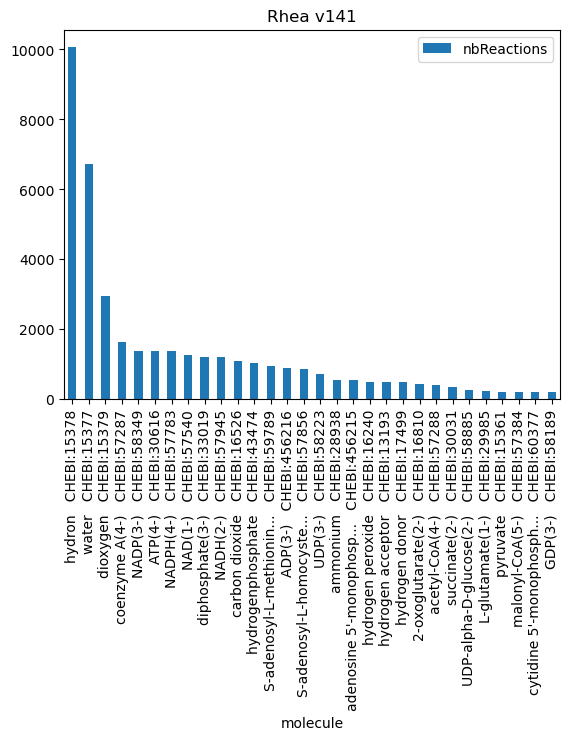

In [26]:
dfMolecules.head(30).plot.bar(x="molecule", y="nbReactions", title="Rhea v{}".format(rheaVersion))

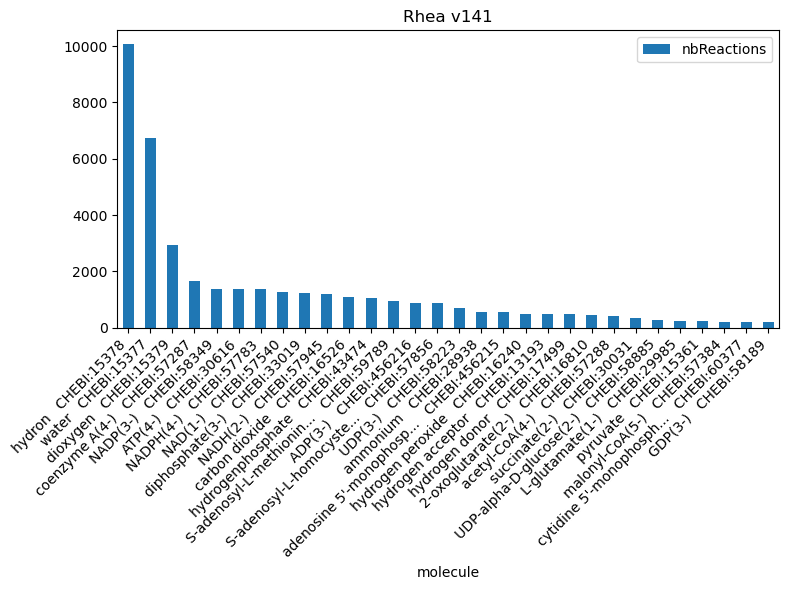

In [27]:
ax = dfMolecules.head(30).plot.bar(x="molecule", y="nbReactions", title="Rhea v{}".format(rheaVersion), figsize=(8, 6))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/rhea_version{}_chebiMoleculesNbReactions.svg".format(rheaVersion), format="svg", bbox_inches="tight")


<Axes: title={'center': 'Rhea v141'}, xlabel='reaction'>

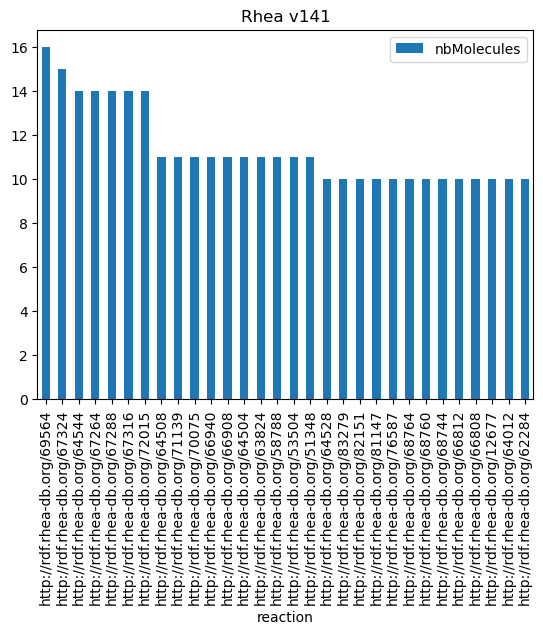

In [28]:
dfReactions.head(30).plot.bar(x="reaction", y="nbMolecules", title="Rhea v{}".format(rheaVersion))